In [2]:
import os
import numpy as np
import xarray as xr
import rioxarray
import geopandas as gpd
from rasterstats import zonal_stats
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings("ignore")


In [2]:

gdf = gpd.read_file("Mapas/Municipio/MGN_ADM_MPIO_GRAFICO.shp", encoding="utf_8")
gdf = gdf.rename(columns={'mpio_cnmbr': 'municipio'})
gdf = gdf[gdf['dpto_cnmbr'] == 'ATLÁNTICO']

In [6]:
print(gdf.head())

    dpto_ccdgo mpio_ccdgo mpio_cdpmp dpto_cnmbr         municipio  \
125         08        001      08001  ATLÁNTICO      BARRANQUILLA   
126         08        078      08078  ATLÁNTICO           BARANOA   
127         08        137      08137  ATLÁNTICO  CAMPO DE LA CRUZ   
128         08        141      08141  ATLÁNTICO        CANDELARIA   
129         08        296      08296  ATLÁNTICO            GALAPA   

                                            mpio_crslc  mpio_tipo  mpio_narea  \
125  Ordenanza 30 del 5 de Mayo de 1913 Ley 44 del ...  MUNICIPIO  154.285925   
126             Ordenanza 11 del 23 de Octubre de 1856  MUNICIPIO  121.350425   
127               Ordenanza 34 del 16 de Abril de 1914  MUNICIPIO   99.995006   
128                                     Ley 27 de 1860  MUNICIPIO  135.766433   
129                                     Ley 37 de 1873  MUNICIPIO   97.515400   

     mpio_nano  shape_Leng  shape_Area  \
125       2024    0.817698    0.012760   
126       2024

# Precipitación 

Procesando 2017...
Procesando 2018...
Procesando 2019...
Procesando 2020...


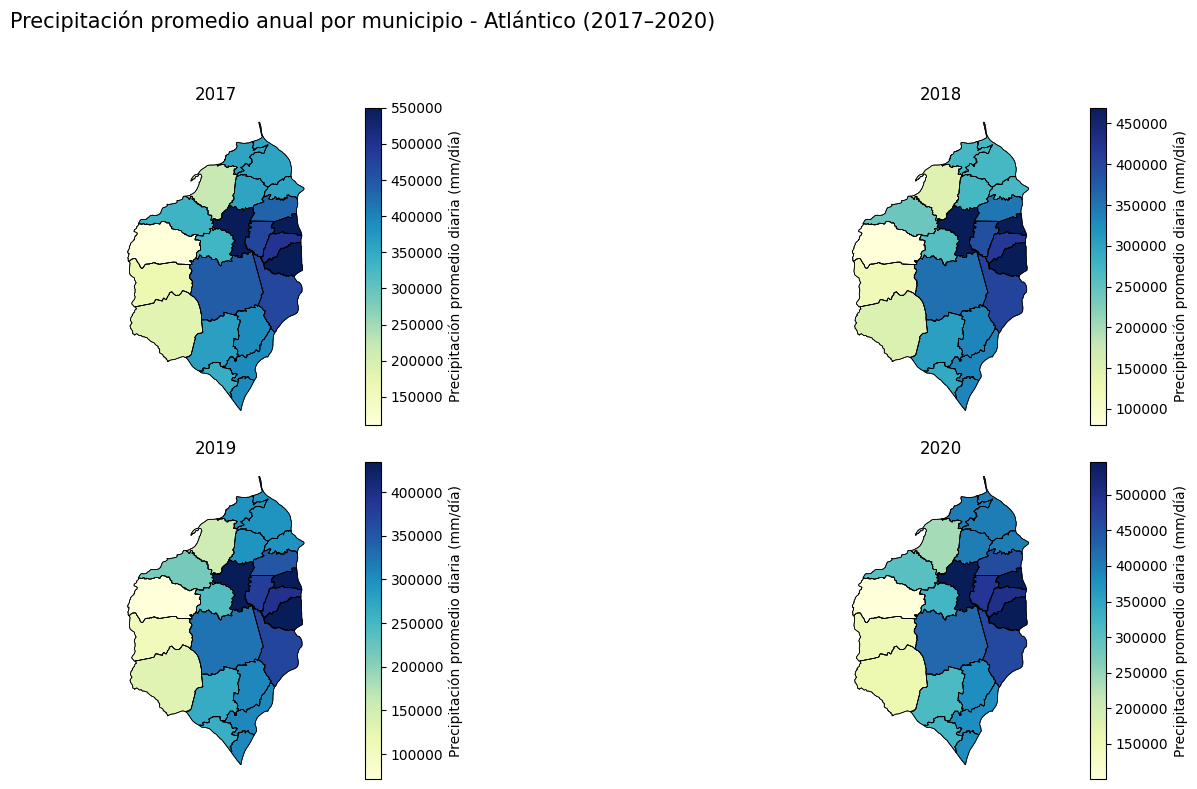

In [3]:
# ------------------------------------------------------------
# 🌧️ Precipitación promedio anual (2017–2020) con escalas individuales
# ------------------------------------------------------------

import os
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from rasterstats import zonal_stats
import rioxarray

# ------------------------------------------------------------
# 1️⃣ Configuración base
# ------------------------------------------------------------
rutas = {
    2017: r"C:\Dengue\Datos Clima\precipitacion_atl_2017",
    2018: r"C:\Dengue\Datos Clima\precipitacion_atl_2018",
    2019: r"C:\Dengue\Datos Clima\precipitacion_atl_2019",
    2020: r"C:\Dengue\Datos Clima\precipitacion_atl_2020"
}

# Shapefile del Atlántico
gdf_base = gpd.read_file("Mapas/Municipio/MGN_ADM_MPIO_GRAFICO.shp", encoding="utf-8")
gdf_base = gdf_base.rename(columns={'mpio_cnmbr': 'municipio'})
gdf_base = gdf_base[gdf_base['dpto_cnmbr'].str.upper() == 'ATLÁNTICO']

# Figura con 4 subplots (2x2)
fig, axes = plt.subplots(2, 2, figsize=(18, 8))
axes = axes.flatten()
cmap = "YlGnBu"

# ------------------------------------------------------------
# 2️⃣ Procesar y graficar cada año con su escala
# ------------------------------------------------------------
for i, (anio, ruta) in enumerate(rutas.items()):
    print(f"Procesando {anio}...")

    # Abrir dataset (todos los archivos del año)
    ds = xr.open_mfdataset(os.path.join(ruta, "*.nc"), combine="by_coords")

    # Variable principal (precipitación)
    var = ds["Precipitation_Flux"].rio.write_crs("EPSG:4326")

    # Convertir unidades a mm/día (si está en kg m⁻² s⁻¹)
    var_mm_dia = var * 86400

    # Promedio anual
    promedio_anual = var_mm_dia.mean(dim="time")

    # Guardar raster temporal
    temp_raster = fr"C:\Dengue\Datos Clima\figs\precipitacion_promedio_anual_{anio}.tif"
    promedio_anual.rio.to_raster(temp_raster)

    # Copiar shapefile
    gdf = gdf_base.copy()

    # Calcular media zonal por municipio
    stats = zonal_stats(gdf, temp_raster, stats="mean", nodata=np.nan)
    gdf["precipitacion_promedio"] = [s["mean"] for s in stats]


    # ------------------------------------------------------------
    # 🔧 Aproximar municipios sin datos con promedio de 5 vecinos más cercanos
    # ------------------------------------------------------------
    from shapely.ops import nearest_points
    from shapely.geometry import Point

    # Centroides de cada municipio
    gdf["centroide"] = gdf.geometry.centroid

    # Municipios con y sin datos
    gdf_con_datos = gdf.dropna(subset=["precipitacion_promedio"])
    gdf_sin_datos = gdf[gdf["precipitacion_promedio"].isna()]

    # Para cada municipio sin datos, estimar valor según 5 vecinos más cercanos
    for idx, row in gdf_sin_datos.iterrows():
        # Calcular distancias a todos los municipios con datos
        gdf_con_datos["dist"] = gdf_con_datos["centroide"].distance(row["centroide"])
        vecinos_cercanos = gdf_con_datos.nsmallest(5, "dist")

        # Promedio de precipitación de los 5 vecinos
        valor_aprox = vecinos_cercanos["precipitacion_promedio"].mean()
        gdf.at[idx, "precipitacion_promedio"] = valor_aprox

    # Limpieza
    gdf.drop(columns="centroide", inplace=True)


    # ------------------------------------------------------------
    # 3️⃣ Graficar cada año con su propia escala
    # ------------------------------------------------------------
    ax = axes[i]
    gdf.boundary.plot(ax=ax, color="black", linewidth=0.5)

    gdf.plot(
        column="precipitacion_promedio",
        cmap=cmap,
        legend=True,
        edgecolor="black",
        linewidth=0.5,
        ax=ax,
        legend_kwds={
            "label": "Precipitación promedio diaria (mm/día)",
            "orientation": "vertical"
        },
        missing_kwds={"color": "white", "edgecolor": "black", "hatch": "///", "label": "Sin datos"}
    )

    ax.set_title(f"{anio}", fontsize=12)
    ax.axis("off")

# ------------------------------------------------------------
# 4️⃣ Ajustes finales
# ------------------------------------------------------------
plt.suptitle("Precipitación promedio anual por municipio - Atlántico (2017–2020)", fontsize=15)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


# Humedad

Procesando 2017...
Procesando 2018...
Procesando 2019...
Procesando 2020...


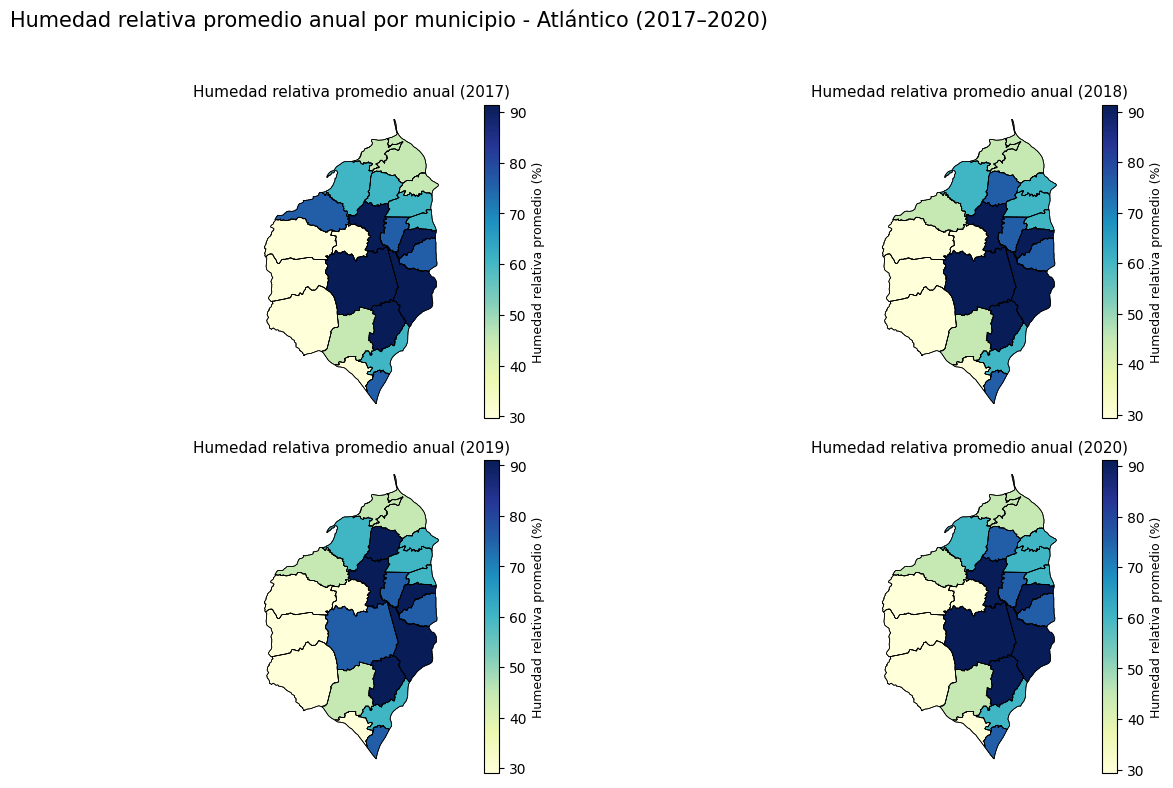

In [4]:
# ------------------------------------------------------------
# 💧 Humedad relativa promedio anual (2017–2020) - Atlántico
# Con escalas individuales (colorbars)
# ------------------------------------------------------------

import os
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from rasterstats import zonal_stats
import mapclassify
import rioxarray

# ------------------------------------------------------------
# 1️⃣ Directorios por año
# ------------------------------------------------------------
rutas = {
    2017: r"C:\Dengue\Datos Clima\humedad_atl_2017",
    2018: r"C:\Dengue\Datos Clima\humedad_atl_2018",
    2019: r"C:\Dengue\Datos Clima\humedad_atl_2019",
    2020: r"C:\Dengue\Datos Clima\humedad_atl_2020"
}

# ------------------------------------------------------------
# 2️⃣ Cargar shapefile del Atlántico
# ------------------------------------------------------------
gdf_base = gpd.read_file("Mapas/Municipio/MGN_ADM_MPIO_GRAFICO.shp", encoding="utf_8")
gdf_base = gdf_base.rename(columns={'mpio_cnmbr': 'municipio'})
gdf_base = gdf_base[gdf_base['dpto_cnmbr'] == 'ATLÁNTICO']

# ------------------------------------------------------------
# 3️⃣ Figura 2x2
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
axes = axes.flatten()
cmap = "YlGnBu"

# ------------------------------------------------------------
# 4️⃣ Procesar cada año
# ------------------------------------------------------------
for i, (anio, ruta) in enumerate(rutas.items()):
    print(f"Procesando {anio}...")

    # Cargar datos netCDF
    ds = xr.open_mfdataset(os.path.join(ruta, "*.nc"), combine="by_coords")

    # Variable: humedad relativa a 2 m (06h)
    var = ds["Relative_Humidity_2m_06h"].rio.write_crs("EPSG:4326")

    # Promedio anual
    promedio_anual = var.mean(dim="time")

    # Guardar raster temporal
    temp_raster = fr"C:\Dengue\Datos Clima\figs\humedad_promedio_anual_atl_{anio}.tif"
    promedio_anual.rio.to_raster(temp_raster)

    # Copiar shapefile
    gdf = gdf_base.copy()

    # Estadísticos zonales
    stats = zonal_stats(
        gdf,
        temp_raster,
        stats="mean",
        nodata=np.nan
    )
    gdf["humedad_promedio"] = [s["mean"] for s in stats]
    
    # ------------------------------------------------------------
    # 🔧 Aproximar municipios sin datos con promedio de 5 vecinos más cercanos
    # ------------------------------------------------------------
    from shapely.ops import nearest_points
    from shapely.geometry import Point

    # Calcular centroides
    gdf["centroide"] = gdf.geometry.centroid

    # Separar municipios con y sin datos
    gdf_con_datos = gdf.dropna(subset=["humedad_promedio"])
    gdf_sin_datos = gdf[gdf["humedad_promedio"].isna()]

    # Para cada municipio sin datos, estimar el valor según sus 5 vecinos más cercanos
    for idx, row in gdf_sin_datos.iterrows():
        # Calcular distancias a los municipios con datos
        gdf_con_datos["dist"] = gdf_con_datos["centroide"].distance(row["centroide"])
        vecinos_cercanos = gdf_con_datos.nsmallest(5, "dist")

        # Calcular promedio simple de la humedad de los vecinos
        valor_aprox = vecinos_cercanos["humedad_promedio"].mean()

        # Asignar valor aproximado
        gdf.at[idx, "humedad_promedio"] = valor_aprox

    # Eliminar la columna auxiliar
    gdf.drop(columns="centroide", inplace=True)


    # ------------------------------------------------------------
    # 5️⃣ Graficar
    # ------------------------------------------------------------
    ax = axes[i]

    # Bordes
    gdf.boundary.plot(ax=ax, color="black", linewidth=0.5)

    # Capa principal
    gdf_plot = gdf.plot(
        column="humedad_promedio",
        cmap=cmap,
        scheme="Quantiles",
        k=5,
        edgecolor="black",
        linewidth=0.5,
        ax=ax,
        missing_kwds={
            "color": "white",
            "edgecolor": "black",
            "hatch": "///",
            "label": "Sin datos"
        }
    )

    # Escala de colores individual
    sm = plt.cm.ScalarMappable(
        cmap=cmap,
        norm=plt.Normalize(
            vmin=gdf["humedad_promedio"].min(),
            vmax=gdf["humedad_promedio"].max()
        )
    )
    sm._A = []
    cbar = fig.colorbar(sm, ax=ax, orientation="vertical", fraction=0.036, pad=0.04)
    cbar.set_label("Humedad relativa promedio (%)", fontsize=9)

    # Título y estilo
    ax.set_title(f"Humedad relativa promedio anual ({anio})", fontsize=11)
    ax.axis("off")

# ------------------------------------------------------------
# 6️⃣ Ajustes finales
# ------------------------------------------------------------
plt.suptitle("Humedad relativa promedio anual por municipio - Atlántico (2017–2020)",
             fontsize=15)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()



# Temperatura

## Maxima

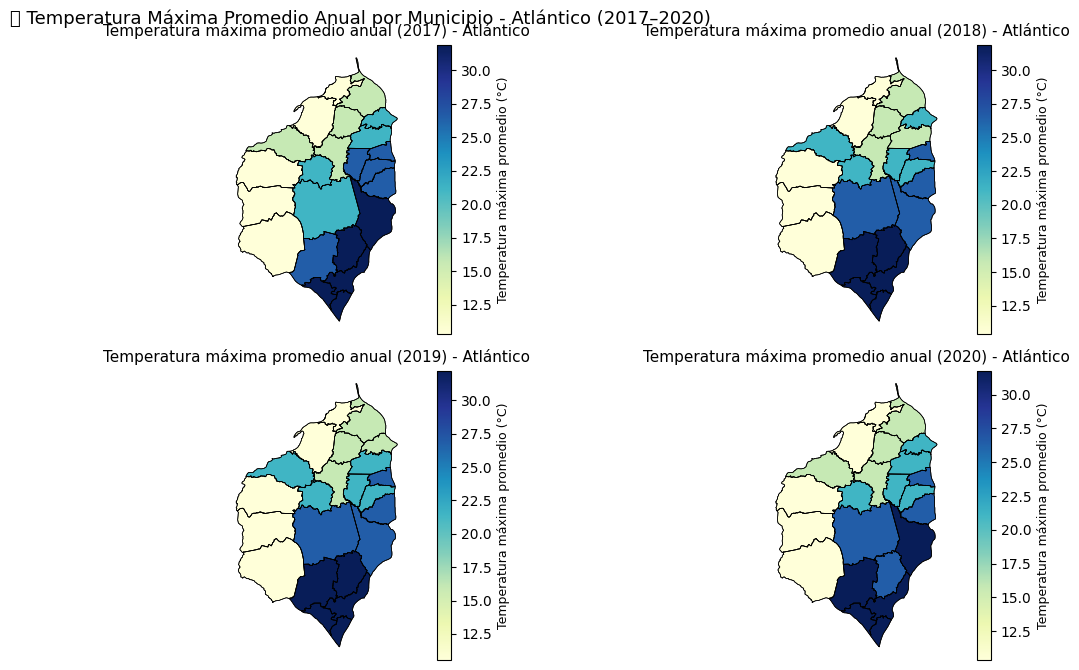

In [8]:
# ------------------------------------------------------------
# 🌡️ Temperatura Máxima Promedio Anual (2017–2020) - Atlántico
# ------------------------------------------------------------
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from rasterstats import zonal_stats
import xarray as xr
import os
import mapclassify

# ------------------------------------------------------------
# 1️⃣ Configuración general
# ------------------------------------------------------------
años = [2017, 2018, 2019, 2020]
base_path = r"C:\Dengue\Datos Clima"
shapefile = r"Mapas/Municipio/MGN_ADM_MPIO_GRAFICO.shp"

# Cargar shapefile del Atlántico
gdf_base = gpd.read_file(shapefile, encoding="utf_8")
gdf_base = gdf_base.rename(columns={'mpio_cnmbr': 'municipio'})
gdf_base = gdf_base[gdf_base['dpto_cnmbr'] == 'ATLÁNTICO']

# ------------------------------------------------------------
# 2️⃣ Crear figura 2x2 y aplanar ejes
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
axes = axes.flatten()  # ✅ para recorrer con un solo índice

# ------------------------------------------------------------
# 3️⃣ Procesar cada año
# ------------------------------------------------------------
for i, año in enumerate(años):
    ruta = fr"{base_path}\temp_max_atl_{año}"

    # Abrir todos los .nc del año y combinarlos
    archivos_nc = [os.path.join(ruta, f) for f in os.listdir(ruta) if f.endswith(".nc")]
    ds = xr.open_mfdataset(archivos_nc, combine="by_coords")

    # Variable de temperatura máxima (convertir de Kelvin a °C)
    var = ds["Temperature_Air_2m_Max_24h"].rio.write_crs("EPSG:4326") - 273.15

    # Promedio anual
    promedio_anual = var.mean(dim="time")

    # Guardar raster temporal
    temp_raster = fr"{base_path}\figs\temp_max_promedio_anual_atl_{año}.tif"
    promedio_anual.rio.to_raster(temp_raster)

    # Copiar shapefile base
    gdf = gdf_base.copy()

    # Calcular promedio por municipio
    stats = zonal_stats(
        gdf,
        temp_raster,
        stats="mean",
        nodata=np.nan
    )
    gdf["temp_max_promedio"] = [s["mean"] for s in stats]
    
    # ------------------------------------------------------------
    # 🔧 Aproximar municipios sin datos con promedio de 5 vecinos más cercanos
    # ------------------------------------------------------------
    from shapely.geometry import Point

    # Calcular centroides
    gdf["centroide"] = gdf.geometry.centroid

    # Separar municipios con y sin datos
    gdf_con_datos = gdf.dropna(subset=["temp_max_promedio"])
    gdf_sin_datos = gdf[gdf["temp_max_promedio"].isna()]

    # Para cada municipio sin datos, estimar el valor según 5 vecinos más cercanos
    for idx, row in gdf_sin_datos.iterrows():
        # Calcular distancias a los municipios con datos
        gdf_con_datos["dist"] = gdf_con_datos["centroide"].distance(row["centroide"])
        vecinos_cercanos = gdf_con_datos.nsmallest(3, "dist")

        # Promedio simple de temperatura máxima de los vecinos
        valor_aprox = vecinos_cercanos["temp_max_promedio"].mean()

        # Asignar valor aproximado
        gdf.at[idx, "temp_max_promedio"] = valor_aprox

    # Eliminar columna auxiliar
    gdf.drop(columns="centroide", inplace=True)


    # --------------------------------------------------------
    # Graficar mapa
    # --------------------------------------------------------
    ax = axes[i]
    cmap = "YlGnBu"

    gdf.boundary.plot(ax=ax, color="black", linewidth=0.5)
    gdf_plot = gdf.plot(
        column="temp_max_promedio",
        cmap=cmap,
        scheme="Quantiles",
        k=5,
        edgecolor="black",
        linewidth=0.5,
        ax=ax,
        missing_kwds={
            "color": "white",
            "edgecolor": "black",
            "hatch": "///",
            "label": "Sin datos"
        }
    )

    # Escala de colores individual
    sm = plt.cm.ScalarMappable(
        cmap=cmap,
        norm=plt.Normalize(
            vmin=gdf["temp_max_promedio"].min(),
            vmax=gdf["temp_max_promedio"].max()
        )
    )
    sm._A = []
    cbar = fig.colorbar(sm, ax=ax, orientation="vertical", fraction=0.036, pad=0.04)
    cbar.set_label("Temperatura máxima promedio (°C)", fontsize=9)

    # Título y estilo
    ax.set_title(f"Temperatura máxima promedio anual ({año}) - Atlántico", fontsize=11)
    ax.axis("off")

# ------------------------------------------------------------
# 4️⃣ Ajuste final
# ------------------------------------------------------------
plt.suptitle("🌡️ Temperatura Máxima Promedio Anual por Municipio - Atlántico (2017–2020)",
             fontsize=13, y=0.95)
plt.tight_layout()
plt.show()


## Minima

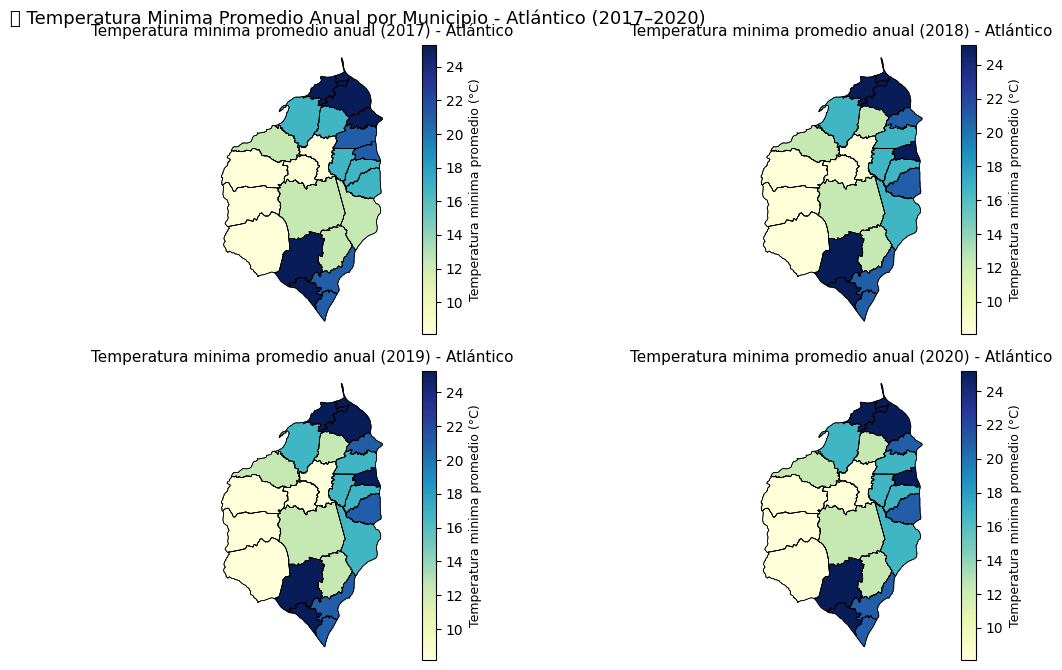

In [7]:
# ------------------------------------------------------------
# 🌡️ Temperatura Máxima Promedio Anual (2017–2020) - Atlántico
# ------------------------------------------------------------
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from rasterstats import zonal_stats
import xarray as xr
import os
import mapclassify

# ------------------------------------------------------------
# 1️⃣ Configuración general
# ------------------------------------------------------------
años = [2017, 2018, 2019, 2020]
base_path = r"C:\Dengue\Datos Clima"
shapefile = r"Mapas/Municipio/MGN_ADM_MPIO_GRAFICO.shp"

# Cargar shapefile del Atlántico
gdf_base = gpd.read_file(shapefile, encoding="utf_8")
gdf_base = gdf_base.rename(columns={'mpio_cnmbr': 'municipio'})
gdf_base = gdf_base[gdf_base['dpto_cnmbr'] == 'ATLÁNTICO']

# ------------------------------------------------------------
# 2️⃣ Crear figura 2x2 y aplanar ejes
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
axes = axes.flatten()  # ✅ para recorrer con un solo índice

# ------------------------------------------------------------
# 3️⃣ Procesar cada año
# ------------------------------------------------------------
for i, año in enumerate(años):
    ruta = fr"{base_path}\temp_min_atl_{año}"

    # Abrir todos los .nc del año y combinarlos
    archivos_nc = [os.path.join(ruta, f) for f in os.listdir(ruta) if f.endswith(".nc")]
    ds = xr.open_mfdataset(archivos_nc, combine="by_coords")

    # Variable de temperatura máxima (convertir de Kelvin a °C)
    var = ds["Temperature_Air_2m_Min_24h"].rio.write_crs("EPSG:4326") - 273.15

    # Promedio anual
    promedio_anual = var.mean(dim="time")

    # Guardar raster temporal
    temp_raster = fr"{base_path}\figs\temp_max_promedio_anual_atl_{año}.tif"
    promedio_anual.rio.to_raster(temp_raster)

    # Copiar shapefile base
    gdf = gdf_base.copy()

    # Calcular promedio por municipio
    stats = zonal_stats(
        gdf,
        temp_raster,
        stats="mean",
        nodata=np.nan
    )
    gdf["temp_min_promedio"] = [s["mean"] for s in stats]
    
    # ------------------------------------------------------------
    # 🔧 Aproximar municipios sin datos con promedio de 5 vecinos más cercanos
    # ------------------------------------------------------------
    from shapely.geometry import Point

    # Calcular centroides
    gdf["centroide"] = gdf.geometry.centroid

    # Separar municipios con y sin datos
    gdf_con_datos = gdf.dropna(subset=["temp_min_promedio"])
    gdf_sin_datos = gdf[gdf["temp_min_promedio"].isna()]

    # Para cada municipio sin datos, estimar el valor según 5 vecinos más cercanos
    for idx, row in gdf_sin_datos.iterrows():
        # Calcular distancias a los municipios con datos
        gdf_con_datos["dist"] = gdf_con_datos["centroide"].distance(row["centroide"])
        vecinos_cercanos = gdf_con_datos.nsmallest(3, "dist")

        # Promedio simple de temperatura máxima de los vecinos
        valor_aprox = vecinos_cercanos["temp_min_promedio"].mean()

        # Asignar valor aproximado
        gdf.at[idx, "temp_min_promedio"] = valor_aprox

    # Eliminar columna auxiliar
    gdf.drop(columns="centroide", inplace=True)


    # --------------------------------------------------------
    # Graficar mapa
    # --------------------------------------------------------
    ax = axes[i]
    cmap = "YlGnBu"

    gdf.boundary.plot(ax=ax, color="black", linewidth=0.5)
    gdf_plot = gdf.plot(
        column="temp_min_promedio",
        cmap=cmap,
        scheme="Quantiles",
        k=5,
        edgecolor="black",
        linewidth=0.5,
        ax=ax,
        missing_kwds={
            "color": "white",
            "edgecolor": "black",
            "hatch": "///",
            "label": "Sin datos"
        }
    )

    # Escala de colores individual
    sm = plt.cm.ScalarMappable(
        cmap=cmap,
        norm=plt.Normalize(
            vmin=gdf["temp_min_promedio"].min(),
            vmax=gdf["temp_min_promedio"].max()
        )
    )
    sm._A = []
    cbar = fig.colorbar(sm, ax=ax, orientation="vertical", fraction=0.036, pad=0.04)
    cbar.set_label("Temperatura minima promedio (°C)", fontsize=9)

    # Título y estilo
    ax.set_title(f"Temperatura minima promedio anual ({año}) - Atlántico", fontsize=11)
    ax.axis("off")

# ------------------------------------------------------------
# 4️⃣ Ajuste final
# ------------------------------------------------------------
plt.suptitle("🌡️ Temperatura Minima Promedio Anual por Municipio - Atlántico (2017–2020)",
             fontsize=13, y=0.95)
plt.tight_layout()
plt.show()
